# Application: Complex Dynamics and Fractals

Explore iterative systems in the complex plane: Newton's method, Julia sets, and chaotic dynamics.

**Prerequisites**: Notebooks #1, #4 | **Time**: ~35 min

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import complexplorer as cp

## What is Complex Dynamics?

**Study of iteration**: $z_{n+1} = f(z_n)$

**Key questions**:
- Does the sequence converge?
- To which limit point (attractor)?
- How does behavior depend on initial $z_0$?

**Applications**:
- Numerical methods (Newton, fixed point)
- Fractal geometry (Julia, Mandelbrot sets)
- Chaos theory
- Holomorphic dynamics (Fatou, Julia)

## 1. Newton's Method for Root Finding

**Goal**: Find roots of $p(z) = 0$

**Iteration**: $$z_{n+1} = z_n - \frac{p(z_n)}{p'(z_n)}$$

**Basins of attraction**: Set of starting points that converge to each root

**Fractal boundaries**: Where basin boundaries meet!

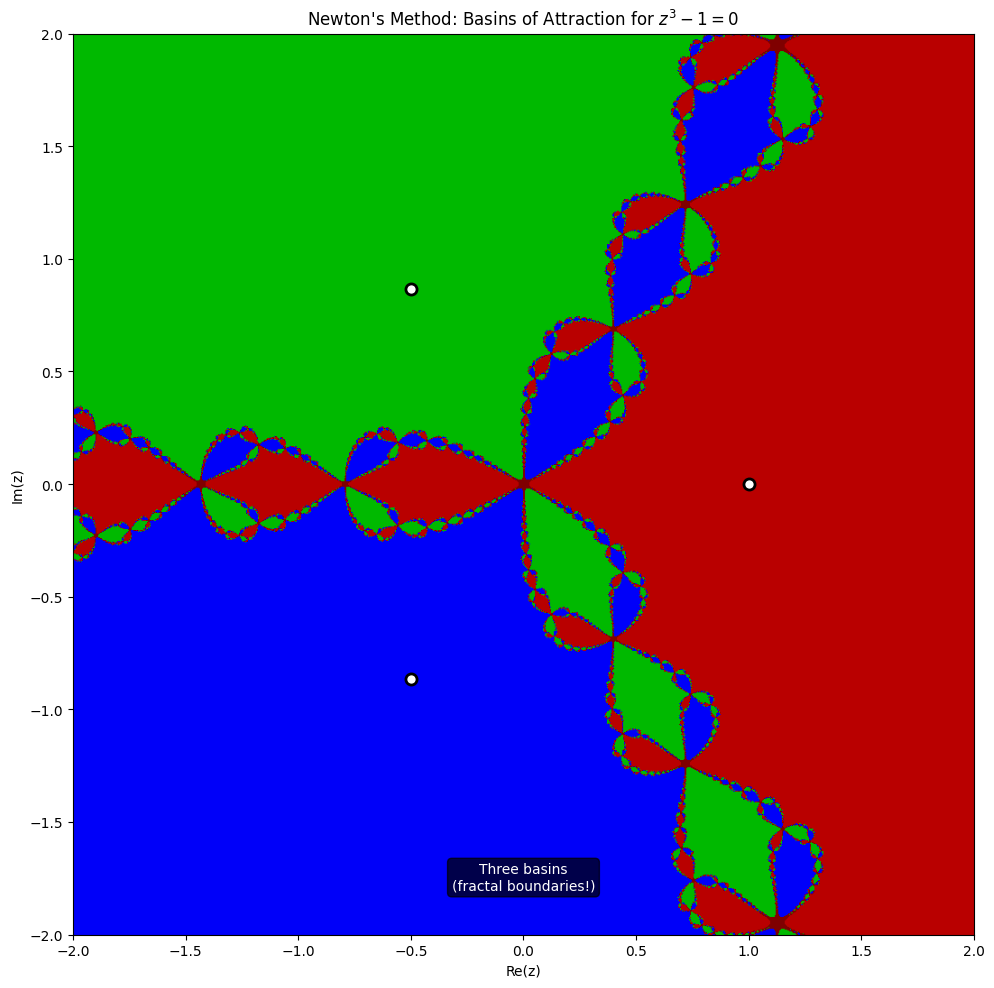


✓ Each colored region converges to a different root!
  The fractal boundaries are where convergence is sensitive to initial conditions


In [2]:
# Newton's method for z^3 - 1 = 0
def newton_cubic(z, max_iter=20, tol=1e-6):
    """Newton iteration for z^3 - 1 = 0.
    
    Returns the root (1, ω, ω²) that z converges to,
    where ω = e^(2πi/3).
    """
    # Three cube roots of unity
    roots = np.array([1, np.exp(2j*np.pi/3), np.exp(4j*np.pi/3)])
    
    result = np.zeros_like(z, dtype=complex)
    
    for i in range(max_iter):
        # Newton iteration: z - (z^3 - 1)/(3z^2)
        z = z - (z**3 - 1) / (3 * z**2 + 1e-10)
    
    # Determine which root z converged to
    for root in roots:
        mask = np.abs(z - root) < tol
        result[mask] = root
    
    return result

domain = cp.Rectangle(re_length=4, im_length=4)
cmap = cp.Phase(phase_sectors=12, auto_scale_r=True)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

cp.plot(domain, newton_cubic, cmap=cmap, ax=ax, resolution=1000)
ax.set_title(r"Newton's Method: Basins of Attraction for $z^3 - 1 = 0$", fontsize=12)

# Mark the three roots
roots = [1, np.exp(2j*np.pi/3), np.exp(4j*np.pi/3)]
for root in roots:
    ax.plot(root.real, root.imag, 'wo', markersize=8, 
            markeredgecolor='black', markeredgewidth=2)

ax.text(0, -1.8, "Three basins\n(fractal boundaries!)", 
        ha='center', fontsize=10, color='white',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✓ Each colored region converges to a different root!")
print("  The fractal boundaries are where convergence is sensitive to initial conditions")

## 2. Higher Degree Polynomials

More roots → more basins → more complex fractals!

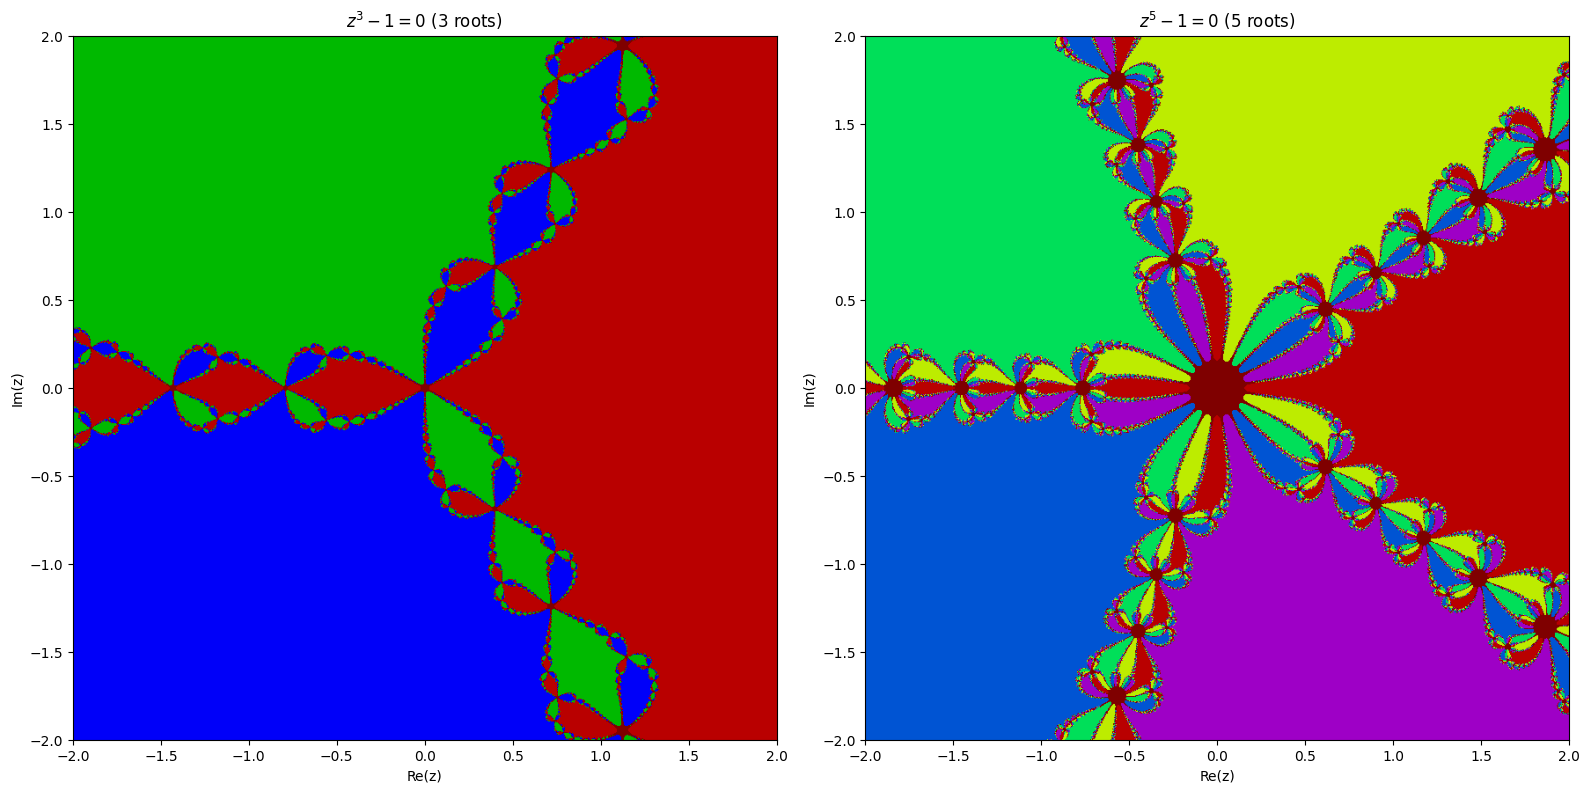


✓ More roots = more complex basin structure!


In [3]:
# Newton's method for z^5 - 1 = 0
def newton_quintic(z, max_iter=30, tol=1e-6):
    """Newton iteration for z^5 - 1 = 0."""
    # Five 5th roots of unity
    roots = np.array([np.exp(2j*np.pi*k/5) for k in range(5)])
    
    result = np.zeros_like(z, dtype=complex)
    
    for i in range(max_iter):
        z = z - (z**5 - 1) / (5 * z**4 + 1e-10)
    
    for root in roots:
        mask = np.abs(z - root) < tol
        result[mask] = root
    
    return result

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# z^3 - 1 (recap)
cp.plot(domain, newton_cubic, cmap=cmap, ax=ax1, resolution=800)
ax1.set_title(r"$z^3 - 1 = 0$ (3 roots)", fontsize=12)

# z^5 - 1
cp.plot(domain, newton_quintic, cmap=cmap, ax=ax2, resolution=800)
ax2.set_title(r"$z^5 - 1 = 0$ (5 roots)", fontsize=12)

plt.tight_layout()
plt.show()

print("\n✓ More roots = more complex basin structure!")

## 3. Julia Sets

**Quadratic family**: $f_c(z) = z^2 + c$

**Julia set $J(f_c)$**: Boundary between bounded and unbounded orbits

**Filled Julia set $K(f_c)$**: Points with bounded orbits

**Connection to Mandelbrot**: $c \in M$ ⟺ $0$ has bounded orbit under $f_c$

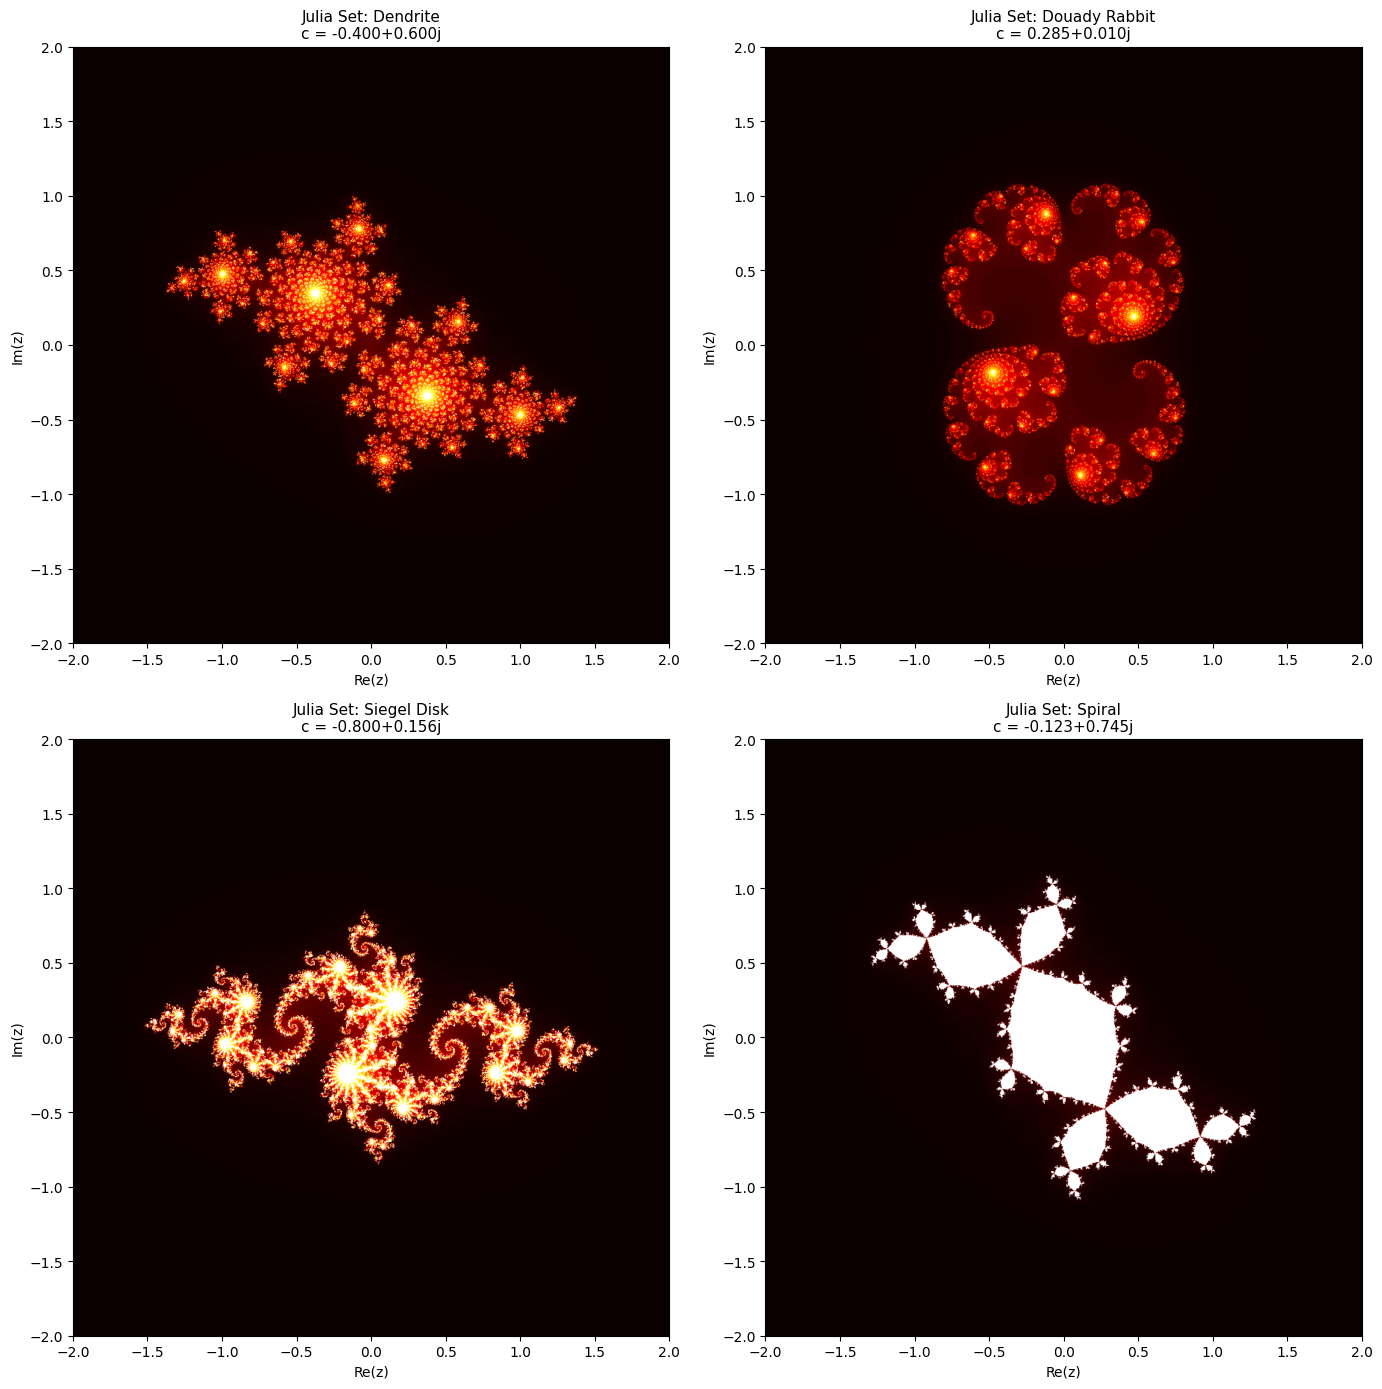


✓ Julia sets show incredible variety!
  Each c value produces a different fractal
  Dark regions = filled Julia set (bounded orbits)


In [4]:
# Julia set visualization (escape time)
def julia_escape_time(z, c=-0.4+0.6j, max_iter=100, escape_radius=2):
    """Compute escape time for Julia set.
    
    Iteration: z → z^2 + c
    Returns number of iterations until |z| > escape_radius
    """
    result = np.zeros(z.shape, dtype=float)
    z_orbit = z.copy()
    
    for i in range(max_iter):
        mask = np.abs(z_orbit) <= escape_radius
        z_orbit[mask] = z_orbit[mask]**2 + c
        result[mask] = i
    
    # Normalize to [0, 1]
    return result / max_iter

def julia_set_colormap(z, c):
    """Color by escape time (grayscale)."""
    escape_time = julia_escape_time(z, c)
    # Return as complex for visualization (use real part for brightness)
    return escape_time + 0j

# Try different c values
c_values = [
    (-0.4 + 0.6j, "Dendrite"),
    (0.285 + 0.01j, "Douady Rabbit"),
    (-0.8 + 0.156j, "Siegel Disk"),
    (-0.123 + 0.745j, "Spiral"),
]

domain_julia = cp.Rectangle(re_length=4, im_length=4)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, (c, name) in enumerate(c_values):
    z = domain_julia.mesh(800)
    escape_time = julia_escape_time(z, c, max_iter=200)
    
    # Smooth coloring
    im = axes[idx].imshow(escape_time, origin='lower', extent=[-2, 2, -2, 2],
                          cmap='hot', interpolation='bilinear')
    axes[idx].set_title(f"Julia Set: {name}\nc = {c:.3f}", fontsize=11)
    axes[idx].set_xlabel('Re(z)')
    axes[idx].set_ylabel('Im(z)')

plt.tight_layout()
plt.show()

print("\n✓ Julia sets show incredible variety!")
print("  Each c value produces a different fractal")
print("  Dark regions = filled Julia set (bounded orbits)")

## 4. Mandelbrot Set Connection

**Mandelbrot set**: $M = \{c \in \mathbb{C} : f_c^n(0) \not\to \infty\}$

**Key insight**: 
- $c \in M$ → filled Julia set is connected
- $c \notin M$ → filled Julia set is a Cantor set (dust)

**Boundary**: $\partial M$ is fractal (Hausdorff dimension ≈ 2)

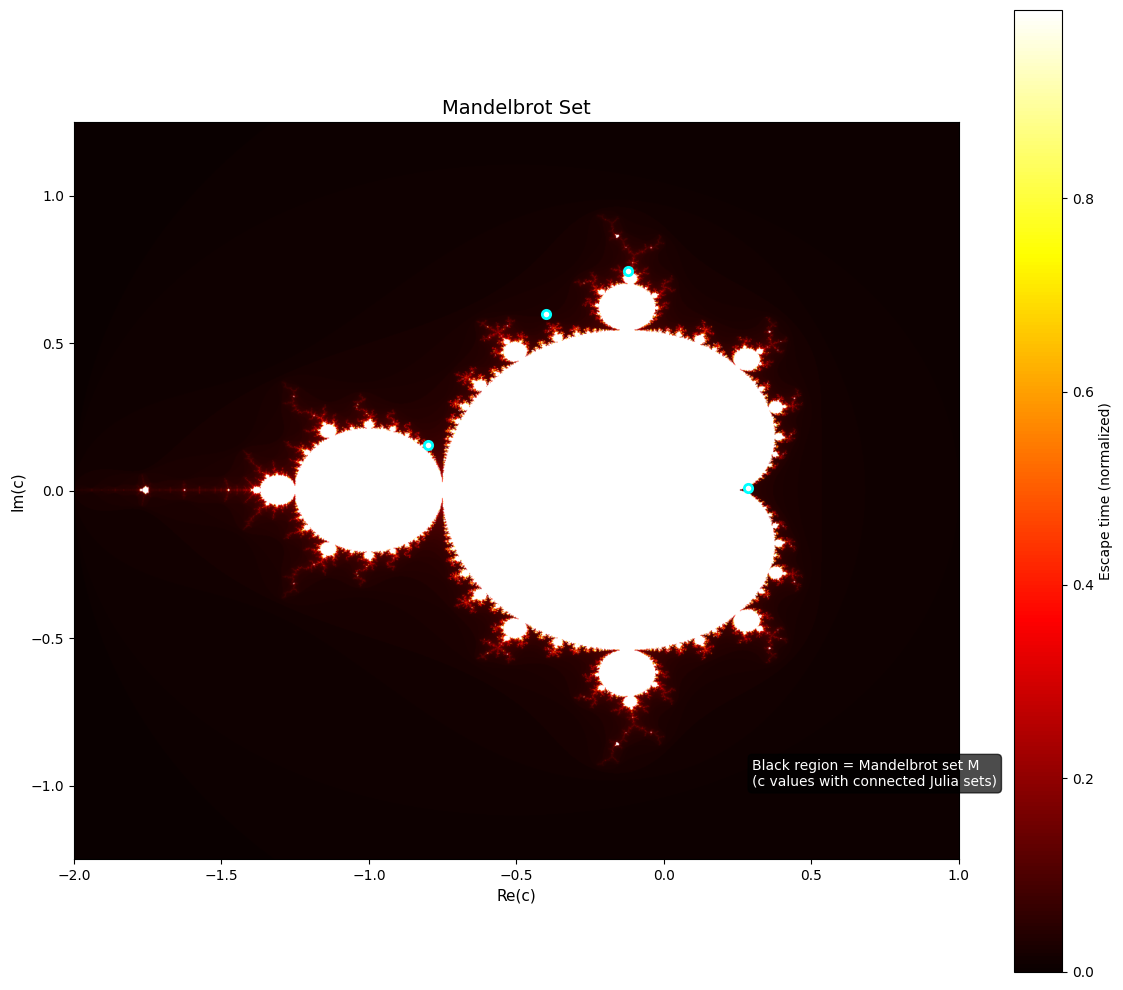


✓ The Mandelbrot set is a catalog of Julia sets!
  White dots = c values from Julia set gallery above


In [5]:
# Mandelbrot set visualization
def mandelbrot_escape_time(c, max_iter=100, escape_radius=2):
    """Compute escape time for Mandelbrot set.
    
    Iteration: z → z^2 + c, starting from z = 0
    """
    result = np.zeros(c.shape, dtype=float)
    z = np.zeros_like(c)
    
    for i in range(max_iter):
        mask = np.abs(z) <= escape_radius
        z[mask] = z[mask]**2 + c[mask]
        result[mask] = i
    
    return result / max_iter

# Zoom into Mandelbrot set
domain_mandel = cp.Rectangle(re_length=3, im_length=2.5, center=-0.5+0j)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

c = domain_mandel.mesh(1200)
escape_time = mandelbrot_escape_time(c, max_iter=200)

im = ax.imshow(escape_time, origin='lower', extent=[-2, 1, -1.25, 1.25],
               cmap='hot', interpolation='bilinear')
ax.set_title("Mandelbrot Set", fontsize=14)
ax.set_xlabel('Re(c)', fontsize=11)
ax.set_ylabel('Im(c)', fontsize=11)

# Mark some interesting c values from Julia set examples
for c_val, name in c_values:
    ax.plot(c_val.real, c_val.imag, 'wo', markersize=6,
            markeredgecolor='cyan', markeredgewidth=2)

ax.text(0.3, -1.0, "Black region = Mandelbrot set M\n(c values with connected Julia sets)",
        fontsize=10, color='white',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.colorbar(im, ax=ax, label='Escape time (normalized)')
plt.tight_layout()
plt.show()

print("\n✓ The Mandelbrot set is a catalog of Julia sets!")
print("  White dots = c values from Julia set gallery above")

## 5. Iteration Visualization

**Final state coloring**: Show where orbits end up

C:\Users\igork\AppData\Local\Temp\ipykernel_35244\2499024680.py:11: RuntimeWarning: overflow encountered in square
  z_orbit = z_orbit**2 + c
C:\Users\igork\AppData\Local\Temp\ipykernel_35244\2499024680.py:11: RuntimeWarning: invalid value encountered in square
  z_orbit = z_orbit**2 + c
c:\Repos\complexplorer\.venv\Lib\site-packages\matplotlib\colors.py:3175: RuntimeWarning: invalid value encountered in cast
  i = (h * 6.0).astype(int)
C:\Repos\complexplorer\complexplorer\core\functions.py:83: RuntimeWarning: overflow encountered in divide
  return np.mod(x / period, 1.0)


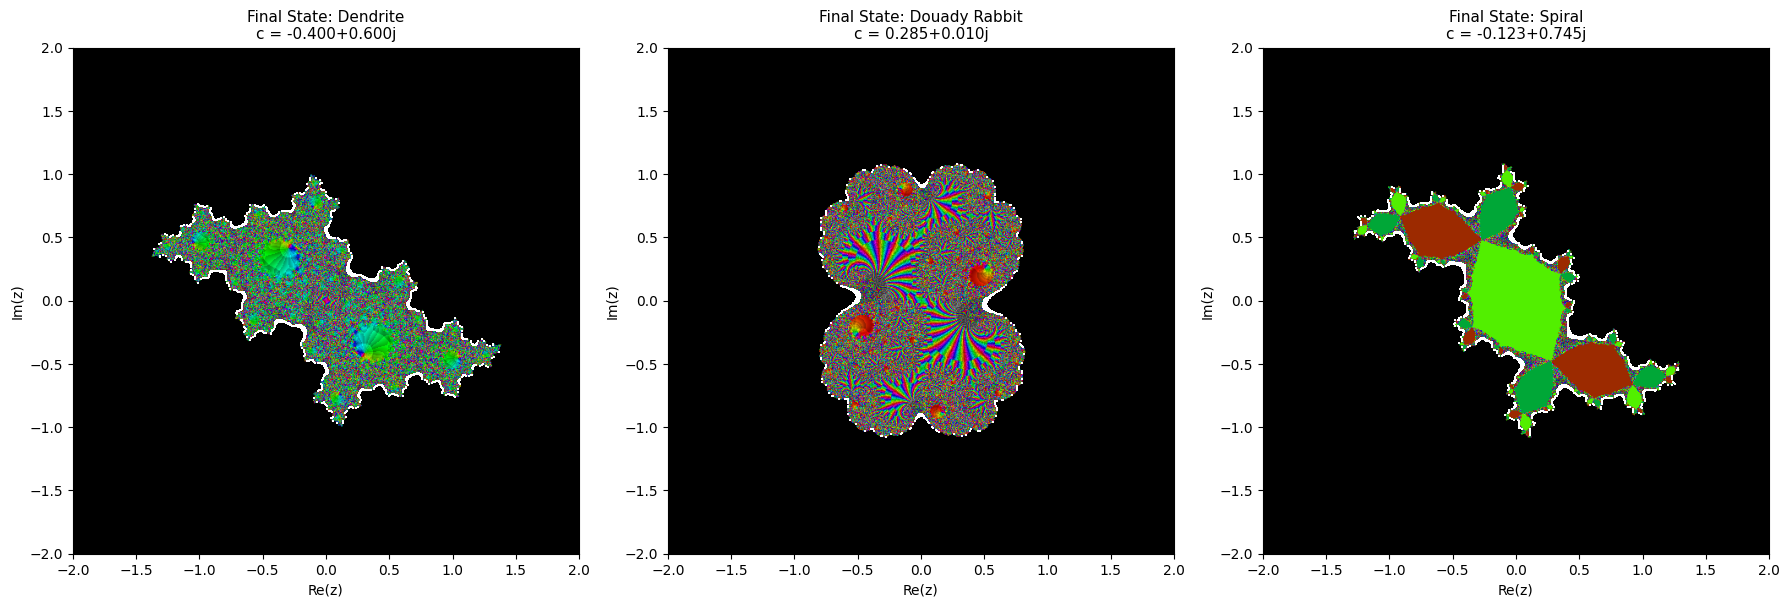


✓ Different c values produce different dynamical behaviors!
  Colors show where initial points end up after many iterations


In [6]:
# Show final position after many iterations
def iterate_quadratic(z, c=-0.4+0.6j, num_iter=50, skip=20):
    """Iterate z → z^2 + c and return final state.
    
    skip: discard first 'skip' iterations (transient)
    """
    z_orbit = z.copy()
    
    # Skip transient
    for i in range(skip):
        z_orbit = z_orbit**2 + c
    
    # Continue iterating
    for i in range(num_iter):
        mask = np.abs(z_orbit) < 100  # Avoid overflow
        z_orbit[mask] = z_orbit[mask]**2 + c
    
    return z_orbit

domain = cp.Rectangle(re_length=4, im_length=4)
cmap = cp.Phase(phase_sectors=16, auto_scale_r=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

c_test = [-0.4+0.6j, 0.285+0.01j, -0.123+0.745j]
names = ["Dendrite", "Douady Rabbit", "Spiral"]

for idx, (c, name) in enumerate(zip(c_test, names)):
    func = lambda z: iterate_quadratic(z, c=c)
    cp.plot(domain, func, cmap=cmap, ax=axes[idx], resolution=600)
    axes[idx].set_title(f"Final State: {name}\nc = {c:.3f}", fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Different c values produce different dynamical behaviors!")
print("  Colors show where initial points end up after many iterations")

## Fractal Dimension and Chaos

### Fractal Properties
- **Self-similarity**: Structure repeats at all scales
- **Non-integer dimension**: Julia sets, Mandelbrot boundary
- **Intricate structure**: Infinite detail

### Chaos
- **Sensitive dependence**: Small changes in $z_0$ → large changes in orbit
- **Unpredictability**: Long-term behavior is chaotic
- **Deterministic chaos**: Simple rules, complex behavior

### Mathematical Significance
- **Fatou sets**: Basins of attraction (stable dynamics)
- **Julia sets**: Boundaries (chaotic dynamics)
- **Classification**: Attracting, repelling, neutral fixed points

## Summary

✅ Newton's method: Fractal basin boundaries
✅ Julia sets: Iteration dynamics for $z^2 + c$
✅ Mandelbrot set: Parameter space of Julia sets
✅ Fractals: Self-similar structure, chaos
✅ Final state coloring: Where orbits converge

## Mathematical Context

Complex dynamics connects:
- **Numerical analysis**: Root finding algorithms
- **Fractal geometry**: Hausdorff dimension, self-similarity
- **Dynamical systems**: Chaos, attractors, bifurcations
- **Complex analysis**: Holomorphic dynamics, Riemann surfaces

## Extensions

### Other Iterations
- **Newton's method**: Other polynomials, rational functions
- **Higher degree**: $z^n + c$
- **Transcendental**: $\lambda e^z$, $\lambda \sin z$

### Advanced Topics
- **Bifurcation diagrams**: Parameter dependence
- **Lyapunov exponents**: Measure of chaos
- **Renormalization**: Feigenbaum constants
- **Hausdorff dimension**: Fractal dimension computation

## Recommended Reading

- Devaney: "An Introduction to Chaotic Dynamical Systems"
- Peitgen & Richter: "The Beauty of Fractals"
- Milnor: "Dynamics in One Complex Variable"
- Mandelbrot: "The Fractal Geometry of Nature"

Where mathematics meets art and chaos! 🎨🌀